In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta
from scipy.stats import invgamma
from scipy.special import betaln
import pandas as pd
from scipy.special import logsumexp
from mpl_toolkits.mplot3d import Axes3D
import pymc as pm

In this lab, we shall go over the analyses of the Kidney cancer and baseball datasets again, and clarify some aspects that were not discussed in class in detail. 

## Kidney Cancer Data Analysis

Here is the dataset. Instead of combining the death counts and population for the two periods 1980-84 and 1985-89, we will only use the data from the first period (as well as the population numbers for the second period), and attempt to predict the death counts for the second period. We will then compare the accuracy of prediction using standard metrics. 

In [2]:
#Read the kidney cancer dataset
import pandas as pd
d_full = pd.read_csv("KidneyCancerClean.csv", skiprows=4)
d = d_full[['state', 'Location', 'fips', 'dc', 'pop', 'dc.2', 'pop.2']].copy()
N = len(d)
x = d['dc'].values
n = d['pop'].values
n2 = d['pop.2'].values #these are the population counts for the second period 1985-1989

The goal is to predict the death counts for the second period. Let us use PyMC. The simplest way of bringing future death counts is include the future death counts as variables in the model. The sampling algorithm will then output posterior samples from $a, b, \theta_1, \dots, \theta_N$ as well as from $Y^{(2)}_1, \dots, Y^{(2)}_N$ (here $Y^{(2)}_i$ is the death count for county $i$ in the second period 1985-89). 

In [3]:
kidney_model = pm.Model()
with kidney_model:
    log_a = pm.Flat("log_a")
    log_b = pm.Flat("log_b")
    a = pm.Deterministic("a", pm.math.exp(log_a))
    b = pm.Deterministic("b", pm.math.exp(log_b))
    theta = pm.Beta("theta", alpha=a, beta=b, shape = N)
    Y = pm.Binomial("Y", n=n, p=theta, observed=x)
    Y2 = pm.Binomial("Y2", n=n2, p=theta)
    #Sample from posterior:
    trace = pm.sample(1000, chains = 4, return_inferencedata = False) 

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [log_a, log_b, theta]
>Metropolis: [Y2]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1697 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Unfortunately the code above takes too long to run (I had to terminate it after 7 minutes). This is because $Y2$ is a discrete variable, PyMC uses one set of algorithms for continuous variables (such as $a, b, \theta_1, \dots, \theta_N$) and another for discrete variables. It can get into a mess while handling both discrete and continuous variable simultaneously, which is what is happening here. 

The fix is to simply remove $Y2$ from the model, and just use the model that we previously used. 

In [4]:
kidney_model = pm.Model()
with kidney_model:
    log_a = pm.Flat("log_a")
    log_b = pm.Flat("log_b")
    a = pm.Deterministic("a", pm.math.exp(log_a))
    b = pm.Deterministic("b", pm.math.exp(log_b))
    theta = pm.Beta("theta", alpha=a, beta=b, shape = N)
    Y = pm.Binomial("Y", n=n, p=theta, observed=x)
    #Sample from posterior:
    trace = pm.sample(1000, chains = 4, return_inferencedata = False) 

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [log_a, log_b, theta]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 33 seconds.
There were 2 divergences after tuning. Increase `target_accept` or reparameterize.
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


This gives, as before, posterior samples from $a, b, \theta_1, \dots, \theta_N$. Now suppose for county $i$, we want to predict the number of deaths (due to kidney cancer) in the next 5 year period: $Y_i^{\text{next}}$, given population over the next 5 year period is $n_i^{\text{next}}$. We can answer this by calculating the conditional distribution: 
\begin{align*}
   X_i^{\text{next}} \mid \text{data}, n_i^{\text{next}}. 
\end{align*}
Write
\begin{align*}
    \mathbb{P} \left\{X_i^{\text{next}} = x\mid \text{data}, n_i^{\text{next}} \right\} &= \int_0^1 \mathbb{P}\left\{X_i^{\text{next}} = x \mid \theta_i, \text{data}, n_i^{\text{next}}\right\} f_{\theta_i \mid \text{data}, n_i^{\text{next}}}(\theta_i) d\theta_i \\
    &= \int_0^1 \mathbb{P}\left\{X_i^{\text{next}} = x \mid \theta_i, n_i^{\text{next}}\right\} f_{\theta_i \mid \text{data}}(\theta_i) d\theta_i \\
    &= \int_0^1 \mathbb{P} \left\{Bin(n_i^{\text{next}}, \theta_i) = x \right\} f_{\theta_i \mid \text{data}}(\theta_i) d\theta_i
\end{align*}
This conditional distribution is sometimes referred to as a Posterior Predictive Distribution. By simulation, this can be done in the following way. For each posterior sample of $\theta_i$, we just simulate $X_i^{\text{next}}$ using the Binomial distribution with $n_i^{\text{next}}$ and $\theta_i$. 

In [5]:
theta_samples = trace.get_values("theta")
n_next = n2
X_next_samples = np.random.binomial(n=n_next[None, :], p=theta_samples)  # shape (M, N)

Below we explore the histograms of predicted death counts for some counties. 

Actual death count for county 935: 5


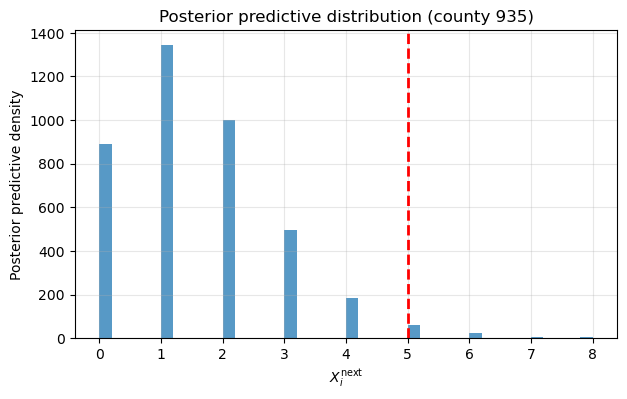

In [6]:
#key_ind = 346
key_ind = 340
key_ind = 575
key_ind = 935
#key_ind = 1624
#key_ind = 1681
x_next_i = X_next_samples[:, key_ind]   # shape (M,)
#Actual death count:
dc2_i = d['dc.2'].values[key_ind]
print(f"Actual death count for county {key_ind}: {dc2_i}")
plt.figure(figsize=(7, 4))
plt.hist(x_next_i, bins=40, density=False, alpha=0.75)
plt.axvline(dc2_i, color='red', linestyle='dashed', linewidth=2, label="Actual death count")
plt.xlabel(r"$X_i^{\mathrm{next}}$")
plt.ylabel("Posterior predictive density")
plt.title(f"Posterior predictive distribution (county {key_ind})")
plt.grid(alpha=0.3)
plt.show()


To check accuracy of predictions, we can simply take the posterior means of the predicted death proportions, and then compare with actual future death proportions. 

In [7]:
#Column wise means of the posterior predictive samples:
X_next_means = X_next_samples.mean(axis=0)  # shape (N,)
nextprop_estimates = X_next_means / n_next

In [8]:
d['naiveproportion1'] = d['dc'] / d['pop'] #these are the naive estimates (frequentist)
#Actual Proportions from the second half of the data:
d['proportion2'] = d['dc.2'] / d['pop.2']

#Prediction Accuracy:
diff_naiveproportion1 = d['naiveproportion1'] - d['proportion2']
sum_abs_diff_naiveproportion1 = diff_naiveproportion1.abs().sum()
sum_squared_diff_naiveproportion1 = (diff_naiveproportion1**2).sum()
kl_loss_naiveproportion1 = (d['proportion2'] * np.log(d['proportion2'] / (d['naiveproportion1'] + 1e-10) + 1e-10)).sum() + ((1 - d['proportion2']) * np.log((1 - d['proportion2']) / (1 - d['naiveproportion1'] + 1e-10) + 1e-10)).sum()
negloglik_naiveproportion1 = -(d['dc.2'] * np.log(d['naiveproportion1'] + 1e-10)).sum() - ((d['pop.2'] - d['dc.2']) * np.log(1 - d['naiveproportion1'] + 1e-10)).sum()

diff_bayes = nextprop_estimates - d['proportion2']
sum_abs_diff_bayes = diff_bayes.abs().sum() 
sum_squared_diff_bayes = (diff_bayes**2).sum()
kl_loss_bayes = (d['proportion2'] * np.log(d['proportion2'] / (nextprop_estimates + 1e-10) + 1e-10)).sum() + ((1 - d['proportion2']) * np.log((1 - d['proportion2']) / (1 - nextprop_estimates + 1e-10) + 1e-10)).sum()
negloglik_bayes = -(d['dc.2'] * np.log(nextprop_estimates + 1e-10)).sum() - ((d['pop.2'] - d['dc.2']) * np.log(1 - nextprop_estimates + 1e-10)).sum() 


allresults_absdiff = np.array([sum_abs_diff_naiveproportion1, sum_abs_diff_bayes])
allresults_squareddiff = np.array([sum_squared_diff_naiveproportion1, sum_squared_diff_bayes])
allresults_klloss = np.array([kl_loss_naiveproportion1, kl_loss_bayes])
allresults_negloglik = np.array([negloglik_naiveproportion1, negloglik_bayes])
print(allresults_absdiff)
print(allresults_squareddiff)
print(allresults_klloss)
print(allresults_negloglik)

[0.12508483 0.10491494]
[1.29012723e-05 8.01849534e-06]
[0.50184892 0.0663507 ]
[290602.92682912 282099.52592349]


In [9]:
#Sort the naiveproportion1 column and print all the rows for counties (only the dc and pop columns) in increasing order of the naiveproportion1 estimates:
d['naiveproportion1'] = d['dc'] / d['pop']
d_sorted = d.sort_values(by='naiveproportion1')
#plot the last 60 rows of the sorted dataframe (only the dc and pop columns) in increasing order of the naiveproportion1 estimates:
pd.set_option("display.max_rows", None)
print(d_sorted[['Location', 'dc', 'pop']].tail(1000))

                                 Location   dc      pop
2048                   Huron County, Ohio    8   130209
472                Putnam County, Georgia    1    16273
190         San Benito County, California    4    65003
1851              Warren County, New York    8   130005
2924            Chelan County, Washington    7   113716
2762                San Juan County, Utah    1    16241
2690                   Rusk County, Texas    5    81154
2855           Lancaster County, Virginia    1    16212
2322      Richland County, South Carolina   25   404962
1494                Holt County, Missouri    1    16198
2171          Washington County, Oklahoma    7   113379
2270           Union County, Pennsylvania    5    80969
617                Macon County, Illinois   17   275135
1057               Perry County, Kentucky    5    80883
2427           Hamilton County, Tennessee   34   549850
2502                    Bee County, Texas    4    64635
625              McHenry County, Illinois   23  

Consider the following two counties, for whom the proportion of deaths due to kidney cancer in the first five year period is nearly the same, but they have quite different  populations. 

In [10]:
key_ind1 = 331
key_ind2 = 2258
print(d.loc[key_ind1, ['Location', 'dc', 'pop', 'naiveproportion1']])
print(d.loc[key_ind2, ['Location', 'dc', 'pop', 'naiveproportion1']])

Location            Miami-Dade County, Florida
dc                                         227
pop                                    3278943
naiveproportion1                      0.000069
Name: 331, dtype: object
Location            Northampton County, Pennsylvania
dc                                                37
pop                                           536374
naiveproportion1                            0.000069
Name: 2258, dtype: object


The Bayesian predictions for the proportion of deaths in the next five year time period for these two counties will be different, even though they have the same proportion of deaths in the first time period. For the large county, the predicted proportions will be more localized, compared to the predicted proportions for the small county. 

Naive proportion estimate for county 331: 6.922962674252037e-05
Naive proportion estimate for county 2258: 6.898171798036445e-05
Actual death count for county 331: 5.973232990714075e-05
Actual death count for county 2258: 7.531146670874546e-05


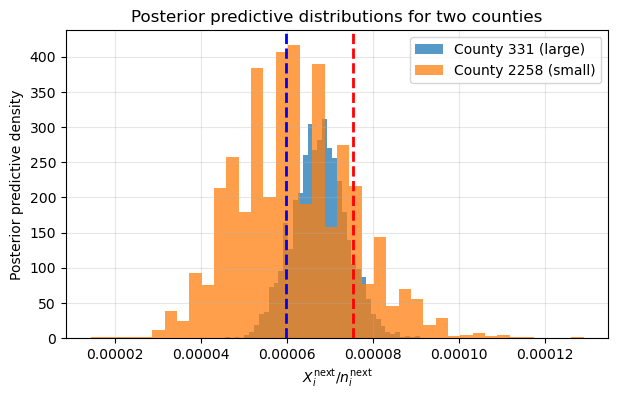

In [23]:
key_ind1 = 331
key_ind2 = 2258
#plot both histograms in one figure: 
prop1 = d['dc'].values[key_ind1] / d['pop'].values[key_ind1]
prop2 = d['dc'].values[key_ind2] / d['pop'].values[key_ind2]
print(f"Naive proportion estimate for county {key_ind1}: {prop1}")
print(f"Naive proportion estimate for county {key_ind2}: {prop2}")

x_next_i1 = X_next_samples[:, key_ind1]/d['pop.2'].values[key_ind1]   # shape (M,)
x_next_i2 = X_next_samples[:, key_ind2]/d['pop.2'].values[key_ind2]   # shape (M,)
#Actual death count:
dc2_i1 = d['dc.2'].values[key_ind1]/d['pop.2'].values[key_ind1]
dc2_i2 = d['dc.2'].values[key_ind2]/d['pop.2'].values[key_ind2]
print(f"Actual death count for county {key_ind1}: {dc2_i1}")
print(f"Actual death count for county {key_ind2}: {dc2_i2}")

plt.figure(figsize=(7, 4))
plt.hist(x_next_i1, bins=40, density=False, alpha=0.75, label=f"County {key_ind1} (large)")
plt.hist(x_next_i2, bins=40, density=False, alpha=0.75, label=f"County {key_ind2} (small)")
plt.axvline(dc2_i1, color='blue', linestyle='dashed', linewidth=2)
plt.axvline(dc2_i2, color='red', linestyle='dashed', linewidth=2)
plt.xlabel(r"$X_i^{\mathrm{next}} / n_i^{\mathrm{next}}$")
plt.ylabel("Posterior predictive density")
plt.title("Posterior predictive distributions for two counties")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

Clearly the blue histogram above is much narrower compared to the orange histogram. 

We can do many interesting things with these future death count samples. We can, for example, compute the counties for which the probability of the future death count is strictly larger than the actual future death count. The counties for which these probabilities are large are those for which the death count in the second period is quite a bit smaller than the death count in the first period. 

In [12]:
#Calculate the posterior probability of the event that the number of deaths in the second period is strictly greater than the actual number of deaths, for all counties: 
dc2 = d['dc.2'].values
probs = np.mean(X_next_samples > dc2, axis=0)
#sort all the counties by these probabilities and print the top 10 counties with the highest probabilities:
sorted_indices = np.argsort(probs)[::-1]  # Sort in descending order
top_30_indices = sorted_indices[:30]
#Print the entire rows of the dataframe corresponding to these top 10 counties (only print thelocation, dc, pop, dc.2, pop.2 columns for these counties):
print("\nDetails of the top 30 counties:")
print(d.loc[top_30_indices, ['Location', 'dc', 'pop', 'dc.2', 'pop.2']])


Details of the top 30 counties:
                             Location   dc       pop  dc.2     pop.2
174    Los Angeles County, California  647  15266402   598  16607891
2539            Coryell County, Texas    3    125257     0    128669
2018              Butler County, Ohio   36    603269    19    638904
2974    Hancock County, West Virginia    5     94284     0     86038
2719             Upshur County, Texas    7     63736     0     66538
291               Bay County, Florida   15    222386     6    260346
684           Elkhart County, Indiana   22    321524    10    350120
2989      Mingo County, West Virginia    4     90703     0     85465
334          Okaloosa County, Florida   21    267269     9    307745
162   Contra Costa County, California   70   1396858    52   1491306
990          Daviess County, Kentucky   16    199899     5    199724
1331          Mower County, Minnesota   10     96237     1     91939
2659         Montgomery County, Texas    9    351250     6    402914
2

## Baseball Dataset

Consider the following baseball dataset (from Chapter 1 of Efron's book on large scale inference). 

In [13]:
baseball = pd.DataFrame({
    "players": [
        "Clemente", "F Robinson", "F Howard", "Johnstone", "Berry",
        "Spencer", "Kessinger", "L Alvarado", "Santo", "Swoboda",
        "Unser", "Williams", "Scott", "Petrocelli", "E Rodriguez",
        "Campaneris", "Munson", "Alvis"
    ],
    "hits": [
        18, 17, 16, 15, 14, 14, 13, 12, 11,
        11, 10, 10, 10, 10, 10, 9, 8, 7
    ],
    "atbats": [45] * 18,
    "EoSaverage": [
        0.346, 0.298, 0.276, 0.222, 0.273, 0.270, 0.263, 0.210,
        0.269, 0.230, 0.264, 0.256, 0.303, 0.264, 0.226,
        0.286, 0.316, 0.200
    ]
})
print(baseball)


        players  hits  atbats  EoSaverage
0      Clemente    18      45       0.346
1    F Robinson    17      45       0.298
2      F Howard    16      45       0.276
3     Johnstone    15      45       0.222
4         Berry    14      45       0.273
5       Spencer    14      45       0.270
6     Kessinger    13      45       0.263
7    L Alvarado    12      45       0.210
8         Santo    11      45       0.269
9       Swoboda    11      45       0.230
10        Unser    10      45       0.264
11     Williams    10      45       0.256
12        Scott    10      45       0.303
13   Petrocelli    10      45       0.264
14  E Rodriguez    10      45       0.226
15   Campaneris     9      45       0.286
16       Munson     8      45       0.316
17        Alvis     7      45       0.200


We take $X_i$ to be the number of hits for player $i$ in the first 45 at bats. Then we take $Y_i = g(X_i)$ and $\theta_i = g(p_i)$ ($p_i$ is the EndofSeason average for player $i$). Here $g(x) = 2 \sqrt{n} \arcsin(\sqrt{x})$. We use the model
\begin{align*}
   Y_i \overset{\text{ind}}{\sim} N(\theta_i, 1). 
\end{align*}
The naive estimator of $\theta_i$ is simply $Y_i$. The accuracy of this estimator is computed below. 

In [14]:
# Apply the transformation: 2 * sqrt(n) * arcsin(sqrt(p))
n = 45
baseball["norm_data"] = 2 * np.sqrt(n) * np.arcsin(np.sqrt(baseball["hits"] / n))
baseball["true_mean"] = 2 * np.sqrt(n) * np.arcsin(np.sqrt(baseball["EoSaverage"]))
print(baseball)

#Accuracy of the naive estimator: 
print(f"Accuracy of the naive estimator: {np.sum((baseball['norm_data'] - baseball['true_mean']) ** 2)}")


        players  hits  atbats  EoSaverage  norm_data  true_mean
0      Clemente    18      45       0.346   9.186472   8.436950
1    F Robinson    17      45       0.298   8.880653   7.747378
2      F Howard    16      45       0.276   8.571275   7.421080
3     Johnstone    15      45       0.222   8.257527   6.582296
4         Berry    14      45       0.273   7.938497   7.375984
5       Spencer    14      45       0.270   7.938497   7.330733
6     Kessinger    13      45       0.263   7.613147   7.224523
7    L Alvarado    12      45       0.210   7.280268   6.386664
8         Santo    11      45       0.269   6.938425   7.315614
9       Swoboda    11      45       0.230   6.938425   6.710614
10        Unser    10      45       0.264   6.585882   7.239751
11     Williams    10      45       0.256   6.585882   7.117400
12        Scott    10      45       0.303   6.585882   7.820536
13   Petrocelli    10      45       0.264   6.585882   7.239751
14  E Rodriguez    10      45       0.22

The James-Stein estimator is given by: 
\begin{align*}
   \hat{\theta}^{JS}_i = \bar{Y}_N + \left(1 - \frac{N-3}{\sum_{i=1}^N(Y_i - \bar{Y}_N)^2} \right) \left(Y_i - \bar{Y}_N \right)
\end{align*}
where $\bar{Y}_N := (Y_1 + \dots + Y_N)/N$ is the mean of the observations $Y_i$. It has much better accuracy compared to the naive estimator. In Lecture 11, we saw how the James-Stein estimator can be derived as an Empirical Bayes estimator. One simply uses the Bayesian model $Y_i \sim N(\theta_i, 1)$ with $\theta_i \sim N(\mu, \tau^2)$, and then plugs in reasonable point estimates for $\mu$ and $\tau$. 

In [15]:
# Mean of normalized data
mu = baseball["norm_data"].mean()
# James–Stein estimator
fctr = 1 - (len(baseball["norm_data"]) - 3) / np.sum((baseball["norm_data"] - mu) ** 2)
baseball["js"] = mu + (baseball["norm_data"] - mu) * fctr
# Compare squared errors in transformed space
print(np.sum((baseball["norm_data"] - baseball["true_mean"]) ** 2), np.sum((baseball["js"] - baseball["true_mean"]) ** 2))

17.610557418678166 5.015274172196248


As an alternative to the James-Stein estimator, we can use the following full Bayes model:
\begin{align*}
   &\text{uninformative priors for } \mu \text{ and } \tau \\
   & \theta_i \mid \mu, \tau \overset{\text{i.i.d}}{\sim} N(\mu, \tau^2) \\
   & y_i \overset{\text{ind}}{\sim} N(\theta_i, 1). 
\end{align*}
What uninformative priors should we picke for $\mu$ and $\tau$? For $\mu$, it is natural to simply use the improper uniform prior on $(-\infty, \infty)$. For $\tau$, the choice is more tricky. 

Integrating out the $\theta_i$'s, we get $y_i \mid \mu, \tau \overset{\text{i.i.d}}{\sim} N(\mu, \tau^2 + \sigma^2)$ (here $\sigma = 1$). So the mean of $y_i$ (in this marginal distribution) is $\mu$ and the variance is $\gamma^2 = \tau^2 + \sigma^2$. For normal distributions, the uniformative prior for the mean is $\text{uniform}(-\infty, \infty)$, and the uninformative prior for the standard deviation $\log \gamma$ is again $\text{uniform}(-\infty, \infty)$, which means that the prior for $\gamma$ is proportional to $1/\gamma$. However, here we have the restriction that $\gamma > \sigma$, so it is natural to use the following prior for $\gamma$: 
\begin{align*}
   f_{\gamma}(\gamma) \propto \frac{I\{\gamma > \sigma\}}{\gamma}. 
\end{align*}
Because $\tau = \sqrt{\gamma^2 - \sigma^2}$, the above prior for $\gamma$ leads to the following prior for $\tau$ (this is by the change of variable formula for densities): 
\begin{align*}
   f_{\tau}(\tau) \propto \frac{\tau}{\tau^2 + \sigma^2} I\{\tau > 0\}. 
\end{align*}
So our overall Bayesian model is: 
\begin{align*}
   & \sigma = 1 \\
   & f_{\mu}(\mu) = 1 ~~ \text{ and } ~~ f_{\tau}(\tau) \propto \frac{\tau}{\tau^2 + \sigma^2} I\{\tau > 0\} \\
   & \theta_i \mid \mu, \tau \overset{\text{i.i.d}}{\sim} N(\mu, \tau^2) \\
   & y_i \overset{\text{ind}}{\sim} N(\theta_i, \sigma^2). 
\end{align*}
In terms of $\gamma$, the model is equivalent to:
\begin{align*}
   & \sigma = 1 \\
   & f_{\mu}(\mu) = 1 ~~ \text{ and } ~~ f_{\gamma}(\gamma) \propto \frac{1}{\gamma} I\{\gamma > \sigma\} \\
   & \theta_i \mid \mu, \gamma \overset{\text{i.i.d}}{\sim} N(\mu, \gamma^2 - \sigma^2) \\
   & y_i \overset{\text{ind}}{\sim} N(\theta_i, \sigma^2). 
\end{align*}
Here is an attempt of implementing this in PyMC.

In [16]:
y_obs = baseball["norm_data"].values
N = len(y_obs)
baseball_model = pm.Model()
with baseball_model:
    mu = pm.Flat("mu")
    log_gamma = pm.HalfFlat("log_gamma") #we are using \log \gamma \sim unif(0, \infty) because sigma = 1 and log sigma = 0
    gamma = pm.Deterministic("gamma", pm.math.exp(log_gamma))
    tau_squared = gamma ** 2 - 1
    theta = pm.Normal("theta", mu=mu, sigma=pm.math.sqrt(tau_squared), shape=N)
    Y = pm.Normal("Y", mu=theta, sigma=1, observed=y_obs)
    trace = pm.sample(2000, chains=4, return_inferencedata=False)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, log_gamma, theta]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 1 seconds.
There were 367 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [17]:
#The accuracy of the full Bayes estimates is given by: 
theta_samples_pymc = trace.get_values("theta")
theta_means_pymc = theta_samples_pymc.mean(axis=0)
print(np.sum((theta_means_pymc - baseball["true_mean"]) ** 2))

5.245014603978636


This accuracy is clearly almost the same as that of the James-Stein estimator. 

In [18]:
baseball['fullbayes_pymc'] = theta_means_pymc
#Let us print the players, norm_data, true_mean, js, fullbayes_pymc columns of baseball:
print(baseball[['players', 'hits', 'norm_data', 'true_mean', 'js', 'fullbayes_pymc']])

        players  hits  norm_data  true_mean        js  fullbayes_pymc
0      Clemente    18   9.186472   8.436950  7.631463        7.741928
1    F Robinson    17   8.880653   7.747378  7.567555        7.654718
2      F Howard    16   8.571275   7.421080  7.502903        7.551806
3     Johnstone    15   8.257527   6.582296  7.437338        7.473277
4         Berry    14   7.938497   7.375984  7.370669        7.380795
5       Spencer    14   7.938497   7.330733  7.370669        7.381619
6     Kessinger    13   7.613147   7.224523  7.302679        7.295569
7    L Alvarado    12   7.280268   6.386664  7.233116        7.202798
8         Santo    11   6.938425   7.315614  7.161679        7.103235
9       Swoboda    11   6.938425   6.710614  7.161679        7.104757
10        Unser    10   6.585882   7.239751  7.088007        7.004153
11     Williams    10   6.585882   7.117400  7.088007        7.009394
12        Scott    10   6.585882   7.820536  7.088007        7.011477
13   Petrocelli    1

Note that PyMC gives some warnings about the markov chains used for calculating the posterior samples. Below we compute the posterior samples of $\theta_1, \dots, \theta_N$ directly. The basic idea is that $y_i \overset{\text{i.i.d}}{\sim} N(\mu, \gamma^2)$ where $\gamma = \sqrt{\tau^2  + \sigma^2}$. From here, we can write the posterior of $\mu$ and $\gamma$ in closed form. The posterior of $\mu, \gamma$ is given by: 
\begin{align*}
   f_{\mu, \gamma \mid y_1, \dots, y_N}(\mu, \gamma) &\propto \frac{I\{\gamma > \sigma\}}{\gamma} \gamma^{-N} \exp \left(-\frac{\sum_{i=1}^N (y_i - \mu)^2}{2\gamma^2}  \right) \\
   &= \frac{I\{\gamma > \sigma\}}{\gamma} \gamma^{-N} \exp \left(-\frac{\sum_{i=1}^N (y_i - \bar{y})^2}{2\gamma^2}  \right) \exp \left(-\frac{N (\bar{y} - \mu)^2}{2\gamma^2}  \right). 
\end{align*}
If $\gamma$ is fixed, it is clear that the density as a function of $\mu$ is Gaussian, so we get
\begin{align*}
    \mu \mid \gamma, y_1, \dots, y_N \sim N(\bar{y}, \gamma^2/N). 
\end{align*}
Then we integrate $\mu$ to get the marginal posterior of $\gamma$: 
\begin{align*}
  f_{\gamma \mid y_1, \dots, y_N}(\gamma) \propto \gamma^{-N} \exp \left(-\frac{\sum_{i=1}^N (y_i - \bar{y})^2}{2 \gamma^2} \right) I\{\gamma > \sigma\}. 
\end{align*}

It is possible to generate samples from this posterior density of $\gamma$. The simplest way is to first observe that without the indicator $I\{\gamma > \sigma\}$, the density is closely related to the Inverse-Gamma density (https://en.wikipedia.org/wiki/Inverse-gamma_distribution). The Inverse Gammma density with shape $\alpha$ and scale $\beta$ is: 
\begin{align*}
   \propto x^{-\alpha - 1} \exp\left(-\beta/x \right) I\{x > 0\}. 
\end{align*}
The posterior density of $\gamma$ has a power of $\gamma^2$ in the exponent so it is not Inverse Gamma. However the posterior of $\gamma^2$ will be Inverse Gamma truncated to the $(\sigma^2, \infty)$. Specifically
\begin{align*}
   f_{\gamma^2 \mid y_1, \dots, y_N}(x) &= f_{\gamma \mid y_1, \dots, y_N}(\sqrt{x}) \frac{1}{2 \sqrt{x}} \\
   &\propto x^{-(N+1)/2} \exp \left(-\frac{\sum_{i=1}^N (y_i - \bar{y})^2}{2 x} \right) I\{x > \sigma^2\}
\end{align*}
Thus the posterior distribution of $\gamma^2$ is Inverse-Gamma($\alpha = (N-1)/2$, $\beta = \sum_{i=1}^N (y_i - \bar{y})^2/2$) truncated to $(\sigma^2, \infty)$. 

### Simulating from a Truncated Inverse Gamma Distribution

Suppose $X$ have a cdf $F_X$. One way of simulating $X$ is by taking $U \sim \text{uniform}(0, 1)$ and then defining $X = F_X^{-1}(U)$. Suppose $Y$ is obtained by truncating $X$ to the interval $(\ell, \infty)$; this means that the cdf of $Y$ is given by
\begin{align*}
 F_Y(y) = \frac{F_X(x) - F_X(\ell)}{1 - F_X(\ell)} I\{x > \ell\}  
\end{align*}
To simulate $Y$, we need to compute the inverse $F_Y^{-1}(u)$. For this, we need to solve
\begin{align*}
   F_Y(y) = u \iff \frac{F_X(x) - F_X(\ell)}{1 - F_X(\ell)} = u \iff F_X(x) = u + (1 - u) F_X(\ell) \implies x = F_X^{-1}(u + (1 - u) F_X(\ell))
\end{align*}
Thus if $U \sim \text{uniform}(0, 1)$, then
\begin{align*}
   Y = F_X^{-1} \left(U + (1 - U) F_X(\ell) \right) 
\end{align*}
is distributed according to $F_Y$. Note that $U + (1 - U) F_X(\ell) \sim \text{uniform}(F_{X}(\ell), 1)$. So we can also write: 
\begin{align*}
   F_X^{-1} \left(\text{uniform}(F_X(\ell), 1) \right) \sim F_Y. 
\end{align*}
Below we use this technique to simuate from the truncated inverse Gamma distribution corresponding to the posterior of $\gamma$. The cdf and inverse cdf for the inverse gamma are inbuilt in scipy. 

 

In [19]:
y = baseball["norm_data"].to_numpy()
N = len(y)
M = 20000 #number of posterior samples
sigma = 1 #known number

ybar = np.mean(y)
S = np.sum((y - ybar) ** 2)

alpha = (N - 1) / 2
beta = S / 2    

v0 = sigma ** 2
F0 = invgamma.cdf(v0, a = alpha, scale = beta)
np.random.seed(123)
u = np.random.uniform(F0, 1, size = M) #this is the uniform(F_X(\ell), 1) random variable
v = invgamma.ppf(u, a = alpha, scale = beta)

gamma_samples = np.sqrt(v)
mu_samples = np.random.normal(loc = ybar, scale = gamma_samples/np.sqrt(N), size = M)

The above code easily simulates posterior samples from $\mu$ and $\gamma$ (or equivalently, $\mu$ and $\tau$). 

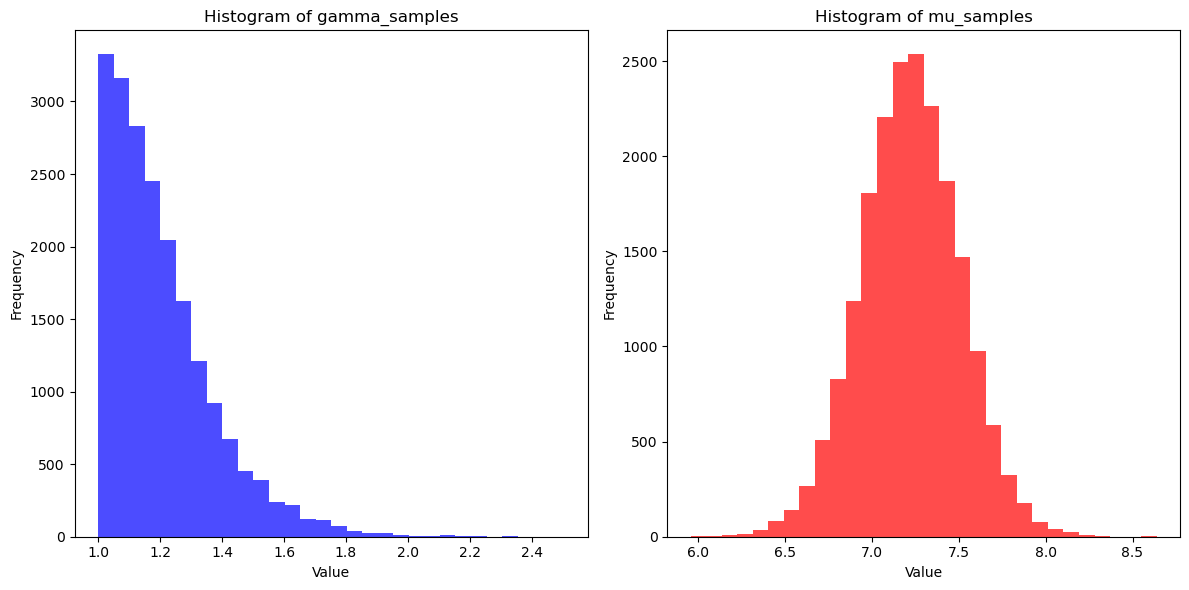

In [20]:

#plotting the histograms of gamma_samples and mu_samples
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

axes[0].hist(gamma_samples, bins=30, color='blue', alpha=0.7, label='a_samples')
axes[0].set_title('Histogram of gamma_samples')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Frequency')

axes[1].hist(mu_samples, bins=30, color='red', alpha=0.7, label='b_samples')
axes[1].set_title('Histogram of mu_samples')
axes[1].set_xlabel('Value')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


For each $\mu$ and $\gamma$, we generate $\theta_1, \dots, \theta_N$ using
\begin{align*}
  \theta_i \mid \mu, \gamma, \text{data} \sim N \left(\mu + \left(1 - \frac{\sigma^2}{\gamma^2} \right) (y_i - \mu),  \sigma^2 \left(1 - \frac{\sigma^2}{\gamma^2} \right)\right). 
\end{align*}
This generates posterior samples of $\theta_1, \dots, \theta_N$.

In [21]:
shrink = 1 - (sigma ** 2)/(gamma_samples ** 2)
theta_mean = mu_samples[:, None] + shrink[:, None] * (y[None, :] - mu_samples[:, None])
theta_var = (sigma ** 2) * shrink
theta_sd = np.sqrt(theta_var)[:, None]
theta_samples = np.random.normal(loc = theta_mean, scale = theta_sd, size = (M, N))

The accuracy of the Bayes estimates are computed below. 

In [22]:
theta_post_mean = theta_samples.mean(axis = 0)
print(np.sum((baseball["norm_data"] - baseball["true_mean"]) ** 2), np.sum((baseball["js"] - baseball["true_mean"]) ** 2), np.sum((theta_post_mean - baseball["true_mean"]) ** 2))

17.610557418678166 5.015274172196248 5.156691134513154


The accuracy is very similar to that given from the PyMC samples, and not very different from the James-Stein estimator's accuracy. 

Below we are printing the James-Stein estimator as well as the full Bayes estimates of each $p_i$ (after applying the inverse transformation from $\theta_i$ to $p_i$). 